# Greedy Adaptive Spline Compression for Quantum Control Signals

Companion file to `autoknots_quantum.py`. Same signals, same structure,
same demos — different algorithm.

---

## What is the Greedy algorithm?

The greedy algorithm is a forward-insertion adaptive spline method. At each
iteration it:
1. Fits a cubic spline to the current knot set
2. Evaluates the approximation error at every point on a dense grid
3. Finds the location of **maximum error** within each contiguous failure region
4. Inserts a new knot exactly at that peak-error location
5. Repeats until all points are within tolerance

### How it differs from AutoKnots

| Property | Greedy | AutoKnots |
|---|---|---|
| Insertion point | Peak-error location | Midpoint of failing interval |
| Error condition | Pointwise only | Pointwise + integral consistency |
| Knot efficiency | ~2× fewer knots | More knots |
| Integral accuracy | Not guaranteed | Controlled to δ |
| Plateau safety | None | Refine pass |

### When to use greedy

- DDR bandwidth is the binding constraint and you need the minimum possible
  number of segments
- You are compressing **amplitude channels** where the waveform shape matters
  but the pulse area is controlled by a separate calibration loop
- You set δ roughly 2–3× tighter than your actual requirement to compensate
  for the integral error not being explicitly controlled

### When to use AutoKnots instead

- You are compressing **frequency or phase channels** where the integral
  of the signal directly determines the gate rotation angle or accumulated phase
- Gate fidelity is the binding constraint rather than DDR bandwidth

---

## Mathematical Foundation

### Cubic spline (not-a-knot, same as AutoKnots)

The spline representation is identical: piecewise cubic polynomials satisfying
C0, C1, C2 continuity at all knots, with not-a-knot boundary conditions giving
$O(h^4)$ accuracy everywhere. See `autoknots_quantum.py` for full derivation.

### Dual error metric

The greedy algorithm uses a **dual absolute + relative** error criterion.
A sample at time $t$ **fails** if both of the following hold simultaneously:

$$|f(t) - \hat{f}(t)| > \varepsilon_{abs} \tag{absolute}$$
$$\frac{|f(t) - \hat{f}(t)|}{|f(t)| + \varepsilon_{scale}} > \varepsilon_{rel} \tag{relative}$$

A sample **passes** if *either* condition is satisfied (AND logic on failure,
OR logic on passing). This means:
- If the absolute error is tiny (signal is near zero), we accept it regardless
  of relative error — prevents infinite refinement at zero crossings
- If the signal is large and relative error is small, we accept it regardless
  of absolute error — prevents over-refinement of high-amplitude regions

The scale parameter $\varepsilon_{scale}$ in the denominator of the relative
error serves the same role as ε in AutoKnots: it floors the denominator so
relative error stays finite near zero.

### Connecting to AutoKnots parameters

AutoKnots has a single tolerance parameter δ. To set greedy parameters to
an equivalent effective tolerance:

$$\varepsilon_{abs} = \delta \cdot (\max|f| + \varepsilon_{scale})$$
$$\varepsilon_{rel} = \delta$$

This is what the `delta` parameter in this file does internally.

### Failure region peak insertion

Rather than inserting one knot globally at the worst error, we find all
**contiguous failure regions** (connected blocks of failing samples) and
insert one knot per region at its local error peak. This gives much faster
convergence on signals with multiple simultaneous failure regions, while
still being more targeted than AutoKnots' midpoint bisection.

Formally: let $\mathcal{R}_1, \mathcal{R}_2, \ldots$ be the connected
components of $\{t : \text{sample fails}\}$. We insert:
$$t_k^* = \arg\max_{t \in \mathcal{R}_k} |f(t) - \hat{f}(t)|$$

### Knot pruning (refinement pass)

After convergence, we attempt to **remove** each interior knot one at a time.
If removing knot $i$ and refitting still satisfies the error criterion
everywhere, the knot was redundant and we discard it. This is the opposite
of AutoKnots' refine step (which adds knots to check for missed features)
and is unique to greedy's forward-insertion structure.

The pruning pass runs in multiple sweeps until no more knots can be removed.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline, interp1d
from scipy.signal import chirp as scipy_chirp
from dataclasses import dataclass, field
from typing import Callable, Optional
import warnings

plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True,
                     'grid.alpha': 0.3, 'font.size': 11})

## Dual error metric

Computed on the full dense grid at every iteration. Returns the absolute
error, the relative error (with scale floor), and a boolean failure mask.

A sample **fails** iff BOTH `e_abs > eps_abs` AND `e_rel > eps_rel`.
It passes if EITHER is within tolerance.

In [4]:
def dual_error(
    f_true:   np.ndarray,
    f_approx: np.ndarray,
    eps_abs:  float,
    eps_rel:  float,
    eps_scale: float,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Compute dual absolute + relative approximation error.

    Parameters
    ----------
    f_true    : true signal values, shape (N,)
    f_approx  : spline approximation values, shape (N,)
    eps_abs   : absolute error threshold
    eps_rel   : relative error threshold
    eps_scale : floor on relative error denominator (prevents divide-by-zero
                near zero crossings; set to ~1% of signal peak or DAC LSB)

    Returns
    -------
    e_abs  : absolute error per sample, shape (N,)
    e_rel  : relative error per sample (scale-regularized), shape (N,)
    failed : True where BOTH errors exceed their thresholds, shape (N,)
    """
    residual = np.abs(f_true - f_approx)
    e_abs    = residual
    e_rel    = residual / (np.abs(f_true) + eps_scale)
    failed   = (e_abs > eps_abs) & (e_rel > eps_rel)
    return e_abs, e_rel, failed

## Failure region detection and peak insertion

Given the failure mask, we find contiguous blocks of failing samples and
return the time of maximum error within each block.

This is more efficient than single global insertion (which would leave the
rest of each failure region unfixed) and more targeted than AutoKnots'
midpoint bisection (which may not land on the worst point).

In [7]:
def failure_region_peaks(
    failed:  np.ndarray,
    t:       np.ndarray,
    e_abs:   np.ndarray,
) -> np.ndarray:
    """
    Find the peak-error time within each contiguous failure region.

    Parameters
    ----------
    failed : boolean failure mask, shape (N,)
    t      : time array, shape (N,)
    e_abs  : absolute error array used for ranking, shape (N,)

    Returns
    -------
    insertion_times : one time per failure region, at the local error peak
    """
    if not np.any(failed):
        return np.array([])

    # Find transitions in the failure mask
    trans  = np.diff(failed.astype(int))
    starts = np.where(trans ==  1)[0] + 1
    ends   = np.where(trans == -1)[0] + 1

    # Handle edge cases where signal starts or ends in a failure region
    if failed[0]:  starts = np.concatenate([[0],          starts])
    if failed[-1]: ends   = np.concatenate([ends, [len(failed)]])

    peaks = []
    for s, e in zip(starts, ends):
        peak_idx = s + np.argmax(e_abs[s:e])
        peaks.append(t[peak_idx])

    return np.array(peaks)

## Result container

In [10]:
@dataclass
class GreedyResult:
    spline:      CubicSpline
    knots:       np.ndarray    # final knot times
    f_at_knots:  np.ndarray    # true f values at knots
    converged:   bool
    n_iterations: int
    n_pruned:    int           # knots removed in pruning pass
    history: list = field(default_factory=list)  # (n_knots, n_fail, max_abs, max_rel)

    @property
    def n_knots(self):    return len(self.knots)
    @property
    def n_segments(self): return len(self.knots) - 1

    def evaluate(self, t: np.ndarray) -> np.ndarray:
        return self.spline(np.asarray(t, dtype=float))

    def ppform(self) -> dict:
        """
        pp-form for hardware upload.

        cs.c shape (4, n_segments): each column i gives [d,c,b,a] where
            S_i(t) = d*(t-ti)^3 + c*(t-ti)^2 + b*(t-ti) + a

        One 32-byte word per segment (4 × float64) maps to the
        ZCU111 spline engine register layout, same as AutoKnots output.
        """
        return {
            'breakpoints':  self.spline.x,
            'coefficients': self.spline.c,
            'n_knots':      self.n_knots,
            'n_segments':   self.n_segments,
            'ddr_bytes':    self.n_segments * 32,
        }

## The Greedy algorithm

In [13]:
def greedy(
    f_func:    Callable,
    t_dense:   np.ndarray,
    delta:     float = 1e-3,
    eps_scale: Optional[float] = None,
    max_knots: int   = 4096,
    prune:     bool  = True,
    prune_passes: int = 5,
    verbose:   bool  = True,
) -> GreedyResult:
    """
    Greedy adaptive cubic spline compression.

    Inserts knots one-per-failure-region at peak-error locations, iterating
    until all samples satisfy the dual absolute+relative error criterion.
    Optionally follows with a pruning pass to remove redundant knots.

    Parameters
    ----------
    f_func    : callable, f(t_array) -> array_like.
    t_dense   : dense evaluation grid, shape (N,). Knot candidates are drawn
                from this grid. Should be fine enough to resolve the signal.
    delta     : relative tolerance. Controls both eps_rel = delta and
                eps_abs = delta * (peak_signal + eps_scale).
                Typical: 1e-3 (0.1%) to 1e-5 (0.001%).
                Set ~2-3× tighter than your actual requirement to compensate
                for integral error not being explicitly controlled.
    eps_scale : floor for relative error denominator, and floor for absolute
                tolerance. Auto-set to 1% of signal peak if None.
                Set to DAC LSB for hardware-grounded threshold.
    max_knots : safety cap on total knot count.
    prune     : if True, attempt to remove redundant knots after convergence.
                Greedy's forward insertion can leave redundant knots in regions
                that were hard early in the iteration but became well-covered
                after neighboring knots were added.
    prune_passes : maximum number of pruning sweeps.
    verbose   : print iteration table.

    Returns
    -------
    GreedyResult
    """
    assert delta > 0, "delta must be positive"

    N  = len(t_dense)
    dt_min = (t_dense[-1] - t_dense[0]) / N   # minimum knot spacing

    # Evaluate true signal on dense grid once
    f_dense = np.asarray(f_func(t_dense), dtype=float)

    # Auto-set eps_scale
    if eps_scale is None:
        peak      = float(np.max(np.abs(f_dense)))
        eps_scale = max(1e-12, 0.01 * peak)
        if verbose:
            print(f"  Auto eps_scale = {eps_scale:.3e}  (1% of peak = {peak:.3e})")

    # Derived absolute threshold: delta × (signal peak + eps_scale)
    # This matches the AutoKnots condition 2.8a when evaluated at the peak
    peak    = float(np.max(np.abs(f_dense)))
    eps_abs = delta * (peak + eps_scale)
    eps_rel = delta

    history   = []
    converged = False
    n_pruned  = 0

    # Initial knot set: just the endpoints
    # (greedy doesn't need 6 initial knots — it builds from 2)
    knots = np.array([t_dense[0], t_dense[-1]], dtype=float)

    if verbose:
        print(f"\n{'═'*60}")
        print(f"  Greedy Adaptive Spline Compression")
        print(f"  [{t_dense[0]:.3e}, {t_dense[-1]:.3e}]")
        print(f"  δ={delta:.1e}  eps_scale={eps_scale:.1e}")
        print(f"  eps_abs={eps_abs:.3e}  eps_rel={eps_rel:.1e}")
        print(f"{'═'*60}")
        print(f"  {'iter':>5} {'knots':>7} {'segs':>6} "
              f"{'fail':>7} {'max_abs':>11} {'max_rel/δ':>11}")
        print(f"  {'·'*56}")

    for iteration in range(max_knots):
        # ── Fit spline on current knot set ────────────────────────────────
        # Get true f values at current knot positions via nearest index on dense grid
        knot_idx = np.searchsorted(t_dense, knots).clip(0, N - 1)
        f_knots  = f_dense[knot_idx]

        bc = 'not-a-knot' if len(knots) >= 4 else 'natural'
        cs = CubicSpline(knots, f_knots, bc_type=bc)

        # ── Evaluate error on full dense grid ─────────────────────────────
        f_approx        = cs(t_dense)
        e_abs, e_rel, failed = dual_error(f_dense, f_approx, eps_abs, eps_rel, eps_scale)

        n_fail   = int(np.sum(failed))
        max_abs  = float(np.max(e_abs))
        max_rel  = float(np.max(e_rel))

        history.append((len(knots), n_fail, max_abs, max_rel))

        if verbose:
            print(f"  {iteration:>5} {len(knots):>7} {len(knots)-1:>6} "
                  f"{n_fail:>7} {max_abs:>11.4e} {max_rel/delta:>11.3f}")

        # ── Convergence check ─────────────────────────────────────────────
        if n_fail == 0:
            converged = True
            if verbose:
                print(f"\n  ✓ Converged in {iteration} iterations — "
                      f"{len(knots)} knots, {len(knots)-1} segments")
            break

        # ── Find insertion points: one per failure region ─────────────────
        new_times = failure_region_peaks(failed, t_dense, e_abs)

        # Filter out candidates too close to existing knots
        # (within half a dense-grid spacing) to avoid numerical singularity
        valid = [nt for nt in new_times
                 if np.min(np.abs(knots - nt)) > dt_min * 0.5]

        if not valid:
            warnings.warn(
                "No valid insertion points found — signal may be at "
                "Nyquist limit of the dense grid. Try a finer t_dense.",
                RuntimeWarning
            )
            break

        if len(knots) + len(valid) > max_knots:
            warnings.warn(
                f"Greedy: adding {len(valid)} knots would exceed "
                f"max_knots={max_knots}. Stopping with {n_fail} failing samples. "
                f"Increase max_knots or relax delta.",
                RuntimeWarning
            )
            break

        knots = np.sort(np.unique(np.concatenate([knots, valid])))

    # Final spline fit
    knot_idx = np.searchsorted(t_dense, knots).clip(0, N - 1)
    f_knots  = f_dense[knot_idx]
    bc       = 'not-a-knot' if len(knots) >= 4 else 'natural'
    cs       = CubicSpline(knots, f_knots, bc_type=bc)

    # ── Pruning pass ──────────────────────────────────────────────────────
    if prune and converged:
        if verbose:
            print(f"\n  {'─'*58}")
            print(f"  Pruning pass: starting with {len(knots)} knots")

        for prune_pass in range(prune_passes):
            n_before = len(knots)
            removed  = 0
            i = 1  # skip first endpoint
            while i < len(knots) - 1:
                # Try removing knot i
                candidate     = np.delete(knots, i)
                cand_idx      = np.searchsorted(t_dense, candidate).clip(0, N-1)
                f_cand        = f_dense[cand_idx]
                bc_c          = 'not-a-knot' if len(candidate) >= 4 else 'natural'
                cs_trial      = CubicSpline(candidate, f_cand, bc_type=bc_c)
                f_trial       = cs_trial(t_dense)
                _, _, failed_trial = dual_error(f_dense, f_trial,
                                                eps_abs, eps_rel, eps_scale)
                if not np.any(failed_trial):
                    # Knot was redundant — remove it
                    knots   = candidate
                    f_knots = f_cand
                    cs      = cs_trial
                    removed += 1
                    n_pruned += 1
                    # Don't increment i — next knot is now at position i
                else:
                    i += 1

            if verbose:
                print(f"  Pass {prune_pass+1}: removed {removed} knots "
                      f"({n_before} → {len(knots)})")
            if removed == 0:
                break

        if verbose:
            print(f"  Pruning complete: {len(knots)} knots remaining "
                  f"({n_pruned} removed total)")

    if verbose:
        pp = (len(knots)-1)*32
        print(f"\n{'═'*60}")
        print(f"  FINAL  {len(knots)} knots | {len(knots)-1} segs | "
              f"{pp} B ({pp/1024:.1f} kB) | conv={converged}")
        print(f"{'═'*60}\n")

    return GreedyResult(
        spline=cs,
        knots=knots,
        f_at_knots=f_dense[np.searchsorted(t_dense, knots).clip(0, N-1)],
        converged=converged,
        n_iterations=iteration + 1,
        n_pruned=n_pruned,
        history=history,
    )

## Multi-channel compression with unified knot grid

Identical strategy to AutoKnots: compress each channel independently,
take the union of knot sets, refit all channels on the unified grid.

In [16]:
def compress_multichannel(
    f_funcs:   dict,
    t_dense:   np.ndarray,
    delta:     float = 1e-3,
    eps_scale: Optional[float] = None,
    max_knots: int   = 4096,
    prune:     bool  = True,
    verbose:   bool  = True,
) -> dict:
    """
    Compress multiple waveform channels to a shared knot grid using Greedy.

    Parameters
    ----------
    f_funcs   : {'channel_name': callable f(t) -> array}
    t_dense   : dense time grid
    delta     : relative tolerance (shared across channels)
    eps_scale : absolute floor (auto if None)
    max_knots : per-channel cap
    prune     : enable pruning pass
    verbose   : print progress

    Returns dict with 'knots', 'splines', 'results', 'ppform'.
    """
    all_knots = [np.array([t_dense[0], t_dense[-1]])]
    per_ch    = {}

    for name, f in f_funcs.items():
        if verbose:
            print(f"\n{'━'*60}")
            print(f"  Channel: {name}")
        res = greedy(f, t_dense, delta=delta, eps_scale=eps_scale,
                     max_knots=max_knots, prune=prune, verbose=verbose)
        per_ch[name] = res
        all_knots.append(res.knots)

    unified = np.unique(np.concatenate(all_knots))
    N = len(t_dense)

    unified_splines = {}
    for name, f in f_funcs.items():
        f_dense = np.asarray(f(t_dense), dtype=float)
        idx     = np.searchsorted(t_dense, unified).clip(0, N-1)
        f_u     = f_dense[idx]
        bc      = 'not-a-knot' if len(unified) >= 4 else 'natural'
        unified_splines[name] = CubicSpline(unified, f_u, bc_type=bc)

    n_segs = len(unified) - 1
    if verbose:
        imax = max(r.n_knots for r in per_ch.values())
        ov   = (len(unified)/imax - 1)*100
        print(f"\n{'━'*60}")
        print(f"  Unified: {len(unified)} knots "
              f"(max-individual: {imax}, overhead: {ov:.0f}%)")

    return {
        'knots':   unified,
        'splines': unified_splines,
        'results': per_ch,
        'ppform':  {
            'n_knots':               len(unified),
            'n_segments':            n_segs,
            'n_channels':            len(f_funcs),
            'ddr_bytes_per_channel': n_segs * 32,
            'total_ddr_bytes':       n_segs * 32 * len(f_funcs),
        }
    }

## Visualization

In [19]:
def plot_result(
    f_func:  Callable,
    t_dense: np.ndarray,
    result:  GreedyResult,
    delta:   float,
    eps_scale: float,
    title:   str = "Greedy Adaptive Spline",
    ylabel:  str = "amplitude",
):
    """4-panel diagnostic plot matching autoknots_quantum.py layout."""
    f_true   = np.asarray(f_func(t_dense), dtype=float)
    f_approx = result.evaluate(t_dense)
    residual = np.abs(f_true - f_approx)
    rel_err  = residual / (np.abs(f_true) + eps_scale + 1e-300)

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    # Signal + spline
    ax = axes[0, 0]
    ax.plot(t_dense*1e6, f_true,   'steelblue', lw=1.5, alpha=0.8, label='Signal')
    ax.plot(t_dense*1e6, f_approx, 'r--',       lw=1.5, alpha=0.9, label='Spline')
    ylim = ax.get_ylim()
    ax.vlines(result.knots*1e6, *ylim, colors='green', alpha=0.2, lw=0.7)
    ax.scatter(result.knots*1e6, result.f_at_knots, s=15, c='green', zorder=5)
    ax.set_ylim(ylim)
    ax.set_xlabel('Time (µs)'); ax.set_ylabel(ylabel)
    ax.set_title(f'{result.n_knots} knots · {result.n_segments} segments '
                 f'({result.n_pruned} pruned)')
    ax.legend(fontsize=9)

    # Absolute error
    ax = axes[0, 1]
    ax.semilogy(t_dense*1e6, residual, 'steelblue', lw=0.8, alpha=0.8)
    peak    = float(np.max(np.abs(f_true)))
    eps_abs = delta * (peak + eps_scale)
    ax.axhline(eps_abs, color='red', ls='--', lw=1.5,
               label=f'eps_abs = δ·(peak+ε) = {eps_abs:.2e}')
    ax.set_xlabel('Time (µs)'); ax.set_ylabel('|f − f̂|')
    ax.set_title('Absolute error'); ax.legend(fontsize=9)

    # Relative error
    ax = axes[1, 0]
    ax.semilogy(t_dense*1e6, rel_err, 'purple', lw=0.8, alpha=0.8)
    ax.axhline(delta, color='red', ls='--', lw=1.5, label=f'δ = {delta:.1e}')
    ax.set_xlabel('Time (µs)'); ax.set_ylabel('|f−f̂|/(|f|+ε)')
    ax.set_title(f'Relative error — eps_scale = {eps_scale:.1e}'); ax.legend(fontsize=9)

    # Convergence
    ax = axes[1, 1]
    if result.history:
        iters = np.arange(len(result.history))
        knts  = [h[0] for h in result.history]
        mabs  = [h[2] for h in result.history]
        mrel  = [h[3] for h in result.history]
        ax2   = ax.twinx()
        ax.plot(iters, knts, 'g-o', ms=4, lw=1.5, label='Knots')
        ax2.semilogy(iters, mabs, 'b-s', ms=3, lw=1.2, alpha=0.8, label='Max |e_abs|')
        ax2.semilogy(iters, [r/delta for r in mrel], 'r-^', ms=3, lw=1.2,
                     alpha=0.8, label='Max e_rel / δ')
        ax2.axhline(1.0, color='gray', ls=':', lw=1, label='δ threshold')
        ax.set_xlabel('Iteration')
        ax.set_ylabel('Knot count', color='green')
        ax2.set_ylabel('Max error')
        ax.set_title('Convergence history')
        l1, lb1 = ax.get_legend_handles_labels()
        l2, lb2 = ax2.get_legend_handles_labels()
        ax.legend(l1+l2, lb1+lb2, fontsize=8)

    plt.tight_layout()
    plt.show()

    pp  = result.ppform()
    raw = len(t_dense) * 8
    print(f"  {result.n_knots} knots | {result.n_segments} segs | "
          f"{pp['ddr_bytes']} B ({pp['ddr_bytes']/1024:.1f} kB) | "
          f"{raw/pp['ddr_bytes']:.1f}× compression | "
          f"converged={result.converged} | pruned={result.n_pruned}\n")

---
## Demo 1: Gaussian-modulated carrier + flat NOP region

Same signal as Demo 1 in `autoknots_quantum.py`.
The NOP region (f ≈ 5×10⁻⁴) tests the eps_scale parameter.
The dual error criterion handles this: the absolute error in the NOP region
is tiny, so the sample passes the absolute condition regardless of relative
error. Greedy correctly places very few knots there.

**Expected result:** significantly fewer knots than AutoKnots on this signal
(~100 vs ~290) because greedy targets the exact peak-error location rather
than bisecting.

DEMO 1: Gaussian carrier + flat NOP region

════════════════════════════════════════════════════════════
  Greedy Adaptive Spline Compression
  [0.000e+00, 1.000e-06]
  δ=1.0e-03  eps_scale=1.0e-03
  eps_abs=7.914e-04  eps_rel=1.0e-03
════════════════════════════════════════════════════════════
   iter   knots   segs    fail     max_abs   max_rel/δ
  ························································
      0       2      1   28436  7.9056e-01     998.950
      1      25     24   49359  2.2429e+00  834462.450
      2      51     50   30937  4.8423e-02   25996.697
      3      85     84   10455  2.7154e-02    6442.609
      4      99     98    1923  2.7981e-03     708.621
      5     103    102       0  7.6148e-04     498.999

  ✓ Converged in 5 iterations — 103 knots, 102 segments

  ──────────────────────────────────────────────────────────
  Pruning pass: starting with 103 knots
  Pass 1: removed 12 knots (103 → 91)
  Pass 2: removed 1 knots (91 → 90)
  Pass 3: removed 0 knots (

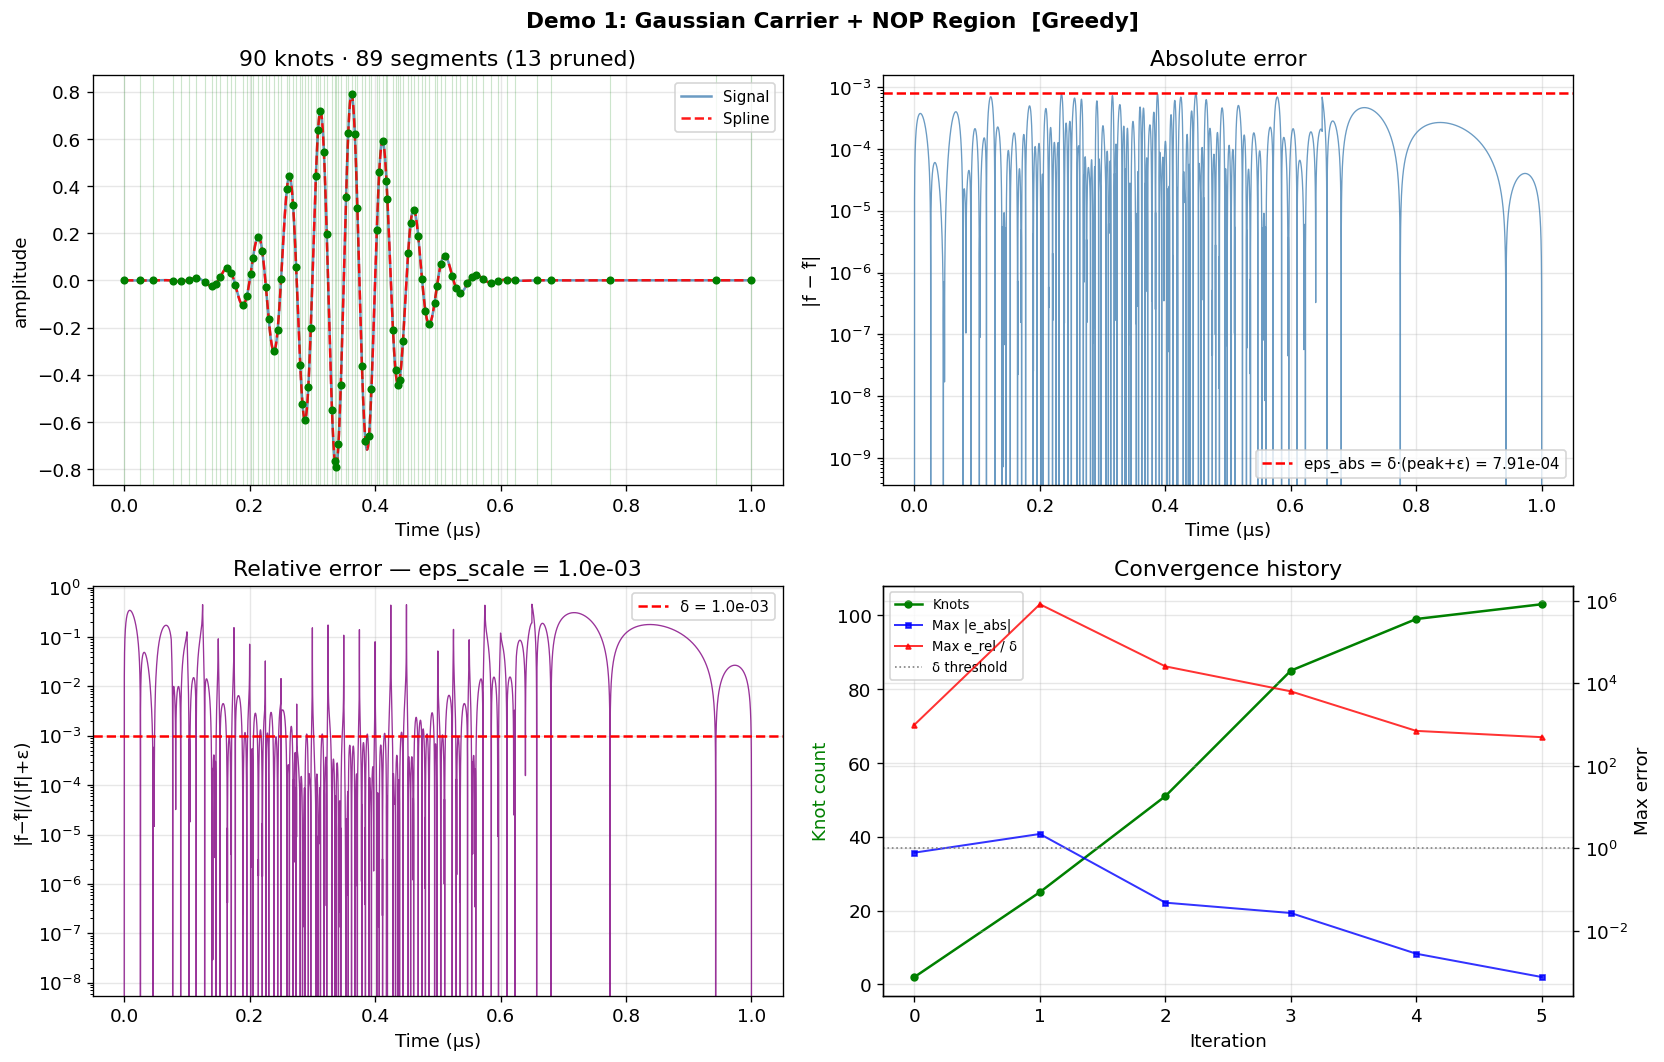

  90 knots | 89 segs | 2848 B (2.8 kB) | 140.4× compression | converged=True | pruned=13



In [22]:
print("=" * 58)
print("DEMO 1: Gaussian carrier + flat NOP region")
print("=" * 58)

N      = 50_000
t_dense = np.linspace(0.0, 1e-6, N)

envelope = np.exp(-0.5 * ((t_dense - 0.35e-6) / 0.08e-6)**2)
_sig1    = np.where(t_dense < 0.65e-6,
                    envelope * np.sin(2*np.pi*20e6*t_dense) * 0.8,
                    5e-4)
_i1 = interp1d(t_dense, _sig1, kind='linear', fill_value='extrapolate')
def f1(t): return _i1(np.asarray(t, dtype=float))

result1 = greedy(
    f1, t_dense,
    delta=1e-3,
    eps_scale=1e-3,    # floor: errors below 1e-3 amplitude units are irrelevant
    prune=True,
    verbose=True,
)
plot_result(f1, t_dense, result1, delta=1e-3, eps_scale=1e-3,
            title="Demo 1: Gaussian Carrier + NOP Region  [Greedy]")

---
## Demo 2: Chirp (5 → 50 MHz)

Frequency sweep that increases difficulty over time. Greedy should
concentrate knots in the high-frequency region where error is worst.
Unlike AutoKnots which bisects blindly, greedy lands precisely on the
highest-error sample within each cycle — typically requiring fewer
knots to resolve each oscillation.

DEMO 2: Chirp (5 → 50 MHz)

════════════════════════════════════════════════════════════
  Greedy Adaptive Spline Compression
  [0.000e+00, 1.000e-06]
  δ=1.0e-03  eps_scale=1.0e-02
  eps_abs=5.100e-04  eps_rel=1.0e-03
════════════════════════════════════════════════════════════
   iter   knots   segs    fail     max_abs   max_rel/δ
  ························································
      0       2      1   49870  9.8996e-01   46829.478
      1      38     37   49501  2.0754e+00  173668.339
      2      84     83   45660  1.1365e+00   72322.415
      3     186    185   26232  1.4847e+00   91388.141
      4     278    277   10391  6.7165e-02    5035.267
      5     326    325    4222  2.1001e-02    1502.887
      6     348    347    1221  2.1205e-03      80.673
      7     361    360       0  4.9816e-04      45.960

  ✓ Converged in 7 iterations — 361 knots, 360 segments

  ──────────────────────────────────────────────────────────
  Pruning pass: starting with 361 knots
  Pass 

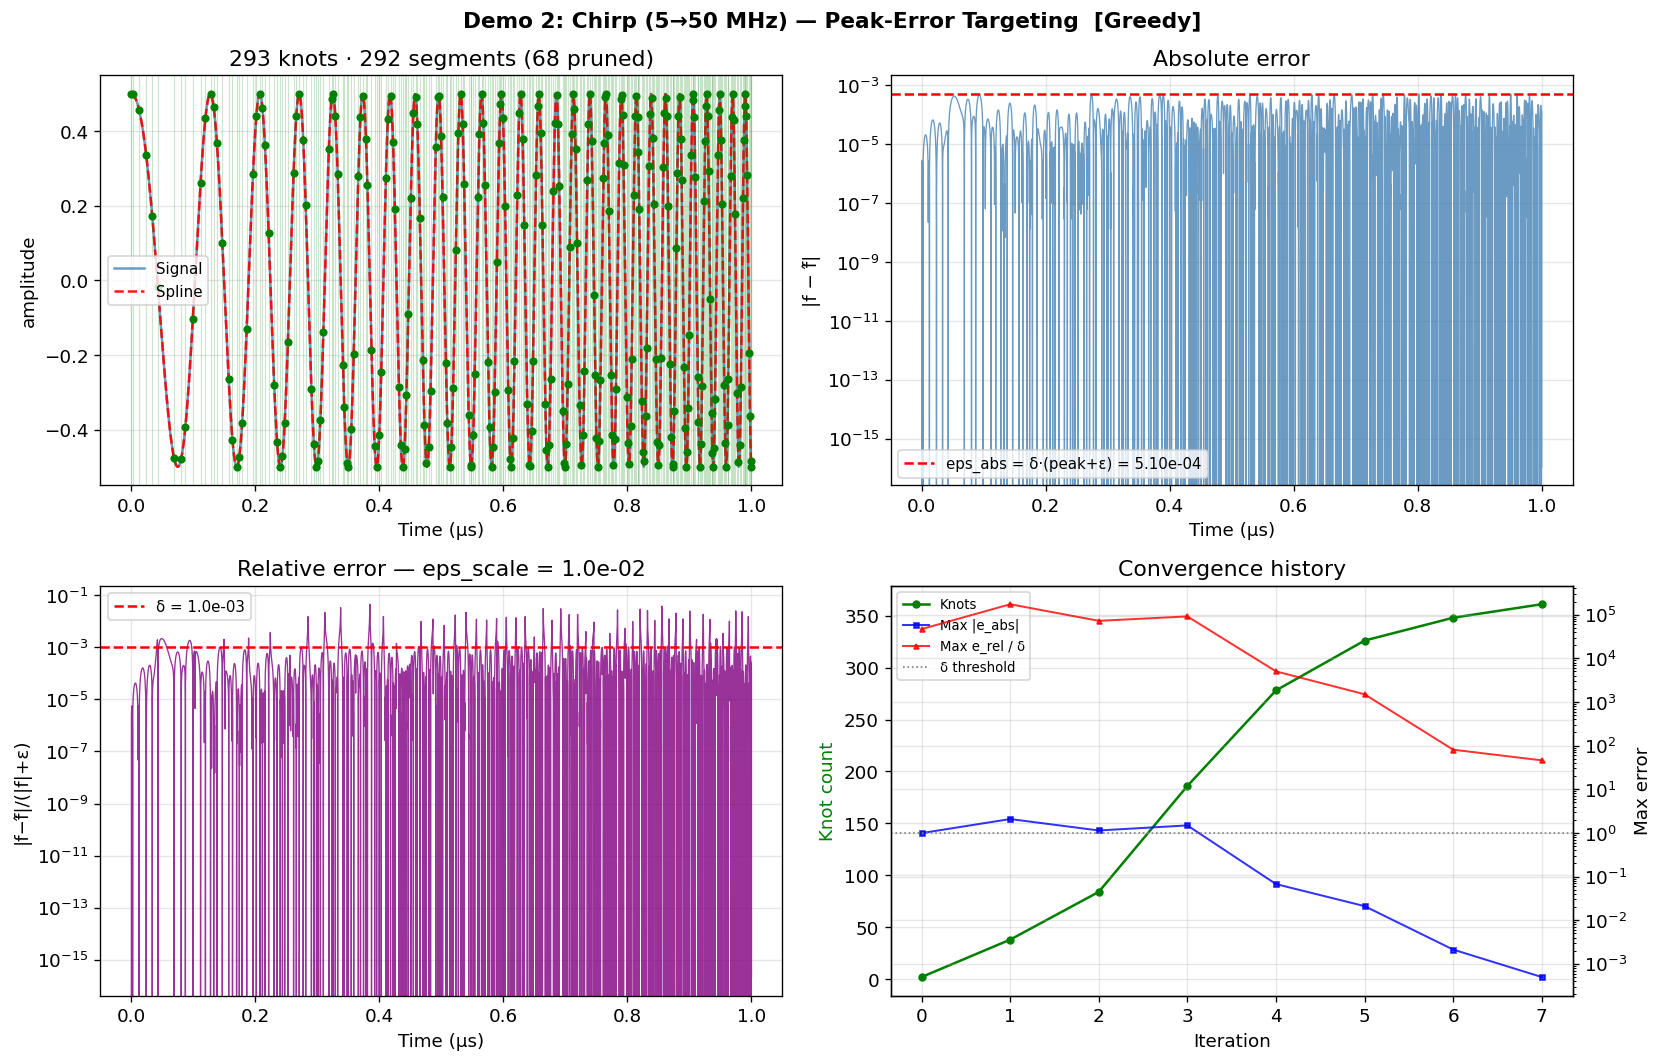

  293 knots | 292 segs | 9344 B (9.1 kB) | 42.8× compression | converged=True | pruned=68



In [24]:
print("=" * 58)
print("DEMO 2: Chirp (5 → 50 MHz)")
print("=" * 58)

_sig2 = scipy_chirp(t_dense, f0=5e6, f1=50e6, t1=1e-6, method='linear') * 0.5
_i2   = interp1d(t_dense, _sig2, kind='linear', fill_value='extrapolate')
def f2(t): return _i2(np.asarray(t, dtype=float))

result2 = greedy(
    f2, t_dense,
    delta=1e-3,
    eps_scale=0.01,
    prune=True,
    verbose=True,
)
plot_result(f2, t_dense, result2, delta=1e-3, eps_scale=0.01,
            title="Demo 2: Chirp (5→50 MHz) — Peak-Error Targeting  [Greedy]")

---
## Demo 3: Multi-gate TIQC sequence

Four concatenated gates. Note that greedy has **no refine/plateau safety net**
— it does not check for hidden features in wide flat intervals. This is
mitigated here by the dense grid (50,000 samples means the evaluation grid
itself has many points inside any interval), but for very sparse initial
grids it can be a problem.

The pruning pass is particularly useful here: greedy inserts knots early in
the algorithm (when the global error is still large) in locations that become
redundant once neighboring knots are added. The pruning pass removes them.

DEMO 3: Multi-gate TIQC sequence

════════════════════════════════════════════════════════════
  Greedy Adaptive Spline Compression
  [0.000e+00, 1.000e-06]
  δ=5.0e-04  eps_scale=5.0e-04
  eps_abs=3.502e-04  eps_rel=5.0e-04
════════════════════════════════════════════════════════════
   iter   knots   segs    fail     max_abs   max_rel/δ
  ························································
      0       2      1   39713  7.0000e-01    1998.572
      1      14     13   49871  4.6585e+00 17885452.059
      2      35     34   47533  2.2811e+00 2391582.226
      3      65     64   44332  1.7591e+00 2631998.869
      4     104    103   41896  1.8320e+00 7328130.032
      5     159    158   26504  1.0456e+00 2208720.422
      6     208    207   16664  2.3585e-01  943381.746
      7     254    253    7430  9.1873e-02  367491.229
      8     296    295    2022  3.5392e-02  141567.297
      9     324    323     496  1.3358e-02   53433.883
     10     336    335      93  4.2551e-03   1702

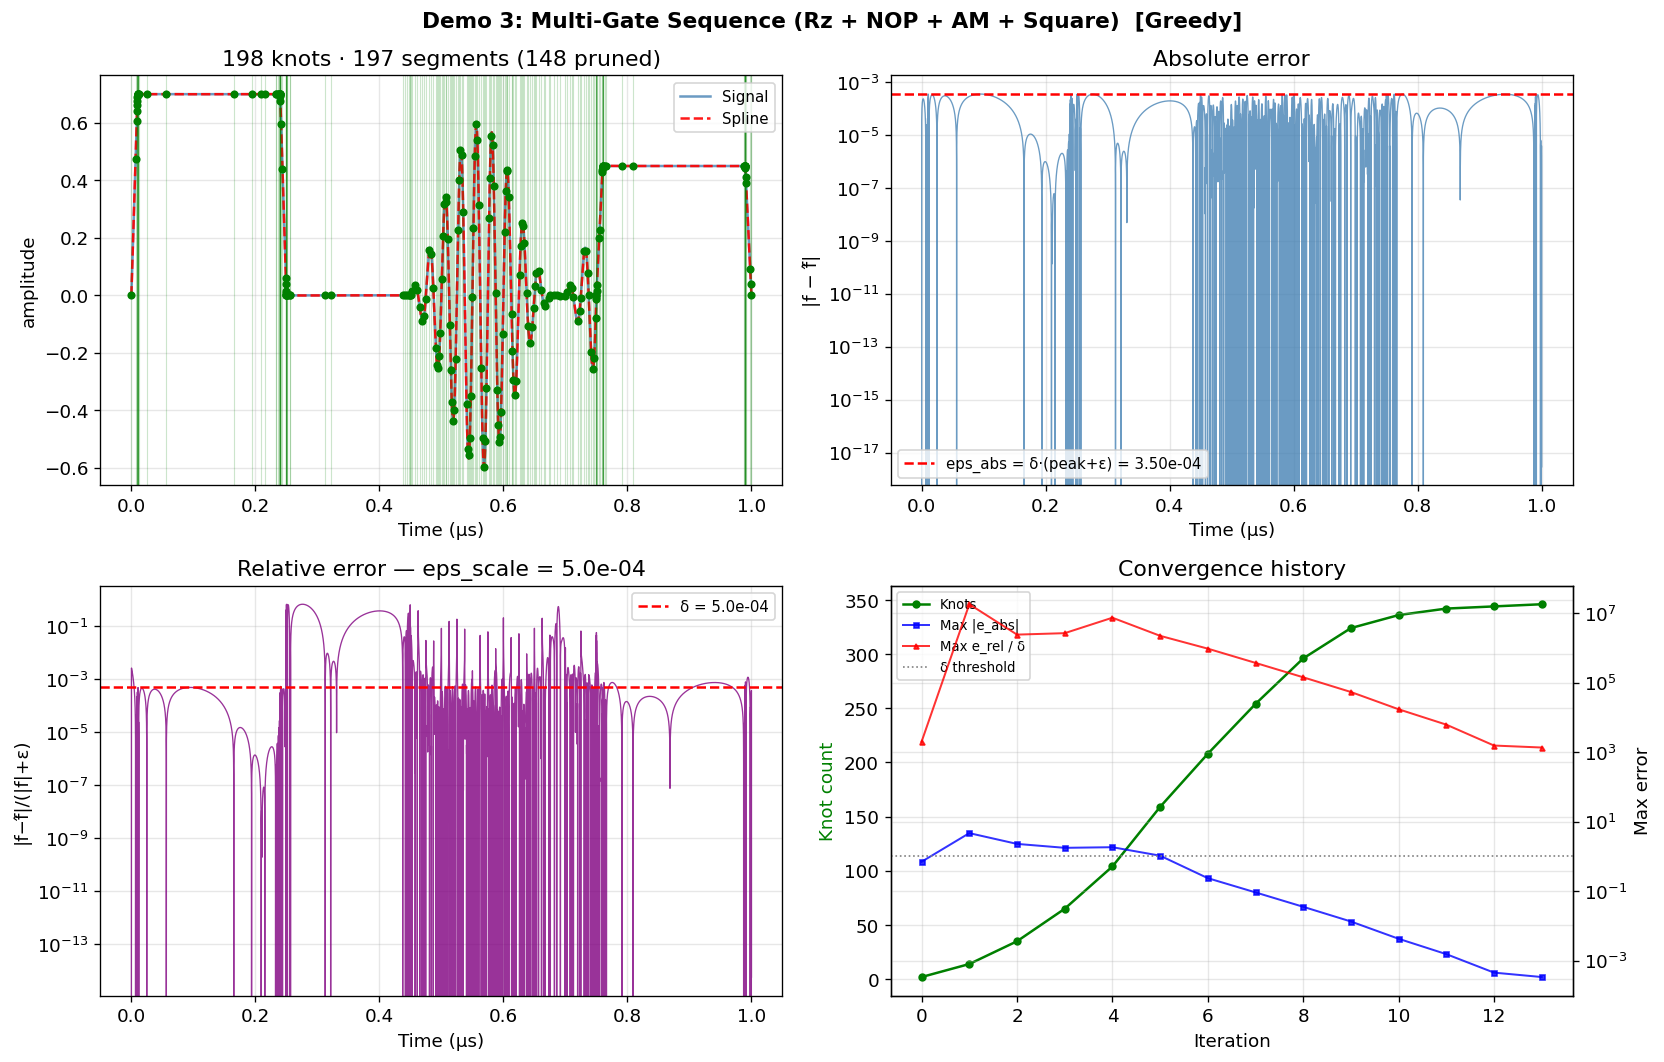

  198 knots | 197 segs | 6304 B (6.2 kB) | 63.5× compression | converged=True | pruned=148



In [27]:
print("=" * 58)
print("DEMO 3: Multi-gate TIQC sequence")
print("=" * 58)

ramp_t = 10e-9
def _ramp(t, t0, t1, A):
    return A * np.minimum(np.clip((t-t0)/ramp_t, 0, 1),
                          np.clip((t1-t)/ramp_t, 0, 1))

_sig3  = np.zeros(N)
_sig3 += _ramp(t_dense, 0, 0.25e-6, 0.7) * (t_dense < 0.25e-6)
mask3  = (t_dense >= 0.45e-6) & (t_dense < 0.75e-6)
am3    = 0.5 * (1 + np.sin(2*np.pi*4e6*t_dense))
_sig3 += mask3 * np.sin(2*np.pi*40e6*t_dense) * am3 * 0.6
_sig3 += _ramp(t_dense, 0.75e-6, 1e-6, 0.45) * (t_dense >= 0.75e-6)
_i3   = interp1d(t_dense, _sig3, kind='linear', fill_value='extrapolate')
def f3(t): return _i3(np.asarray(t, dtype=float))

result3 = greedy(
    f3, t_dense,
    delta=5e-4,
    eps_scale=5e-4,
    prune=True,
    verbose=True,
)
plot_result(f3, t_dense, result3, delta=5e-4, eps_scale=5e-4,
            title="Demo 3: Multi-Gate Sequence (Rz + NOP + AM + Square)  [Greedy]")

---
## Demo 4: Multi-channel (amplitude + frequency + phase)

In [ ]:
print("=" * 58)
print("DEMO 4: Multi-channel compression  [Greedy]")
print("=" * 58)

_sa = (np.exp(-0.5*((t_dense-0.5e-6)/0.15e-6)**2)
       * np.sin(2*np.pi*20e6*t_dense) * 0.9)
_sf = np.linspace(-0.05, 0.05, N)
_sp = np.where(t_dense < 0.5e-6, 0.0, np.pi/8)

ia  = interp1d(t_dense, _sa, kind='linear', fill_value='extrapolate')
iff = interp1d(t_dense, _sf, kind='linear', fill_value='extrapolate')
ip  = interp1d(t_dense, _sp, kind='linear', fill_value='extrapolate')

mc = compress_multichannel(
    f_funcs={
        'amplitude': lambda t: ia( np.asarray(t, dtype=float)),
        'freq':      lambda t: iff(np.asarray(t, dtype=float)),
        'phase':     lambda t: ip( np.asarray(t, dtype=float)),
    },
    t_dense=t_dense,
    delta=1e-3,
    eps_scale=1e-3,
    prune=True,
    verbose=True,
)

print(f"\n  Per-channel:")
for name, res in mc['results'].items():
    print(f"    {name:<15}: {res.n_knots} knots "
          f"(pruned {res.n_pruned})")
pp = mc['ppform']
print(f"\n  Unified: {pp['n_knots']} knots · {pp['n_segments']} segments")
print(f"  DDR total (3 ch): {pp['total_ddr_bytes']} B "
      f"({pp['total_ddr_bytes']/1024:.1f} kB)")

---
## Demo 5: K(δ) scaling

Greedy should follow the same theoretical K ∝ δ^{-1/4} scaling as AutoKnots
for smooth signals, but with a lower prefactor — fewer knots for the same δ.
The slope should be the same; the line should sit lower.

In [ ]:
print("=" * 58)
print("DEMO 5: Knot count vs tolerance (chirp signal)  [Greedy]")
print("=" * 58)

delta_sweep = np.logspace(-2, -5, 10)
K_vals = []

print(f"\n  {'delta':>10} {'K':>7} {'segs':>7} {'ddr kB':>9} {'pruned':>8}")
print(f"  {'─'*46}")

for d in delta_sweep:
    e = max(d * 0.01, 1e-8)
    r = greedy(f2, t_dense, delta=d, eps_scale=e,
               prune=True, verbose=False)
    K_vals.append(r.n_knots)
    print(f"  {d:>10.2e} {r.n_knots:>7} {r.n_segments:>7} "
          f"{r.n_segments*32/1024:>9.2f} {r.n_pruned:>8}")

slope, intercept = np.polyfit(np.log10(delta_sweep), np.log10(K_vals), 1)
fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(delta_sweep, K_vals, 'ro-', ms=8, lw=2, label='Greedy')
d2 = np.array([delta_sweep[0], delta_sweep[-1]])
ax.loglog(d2, 10**(intercept+slope*np.log10(d2)), 'r--', lw=1.5,
          label=f'Fit: K ∝ δ^{{{slope:.3f}}}')
ax.loglog(d2, K_vals[-1]*(d2/d2[-1])**(-0.25), 'g:', lw=1.5,
          label='Theory: K ∝ δ^{-0.25}')
ax.set_xlabel('δ'); ax.set_ylabel('K')
ax.set_title('K(δ) scaling — Greedy on chirp signal')
ax.legend(); plt.tight_layout(); plt.show()
print(f"\n  Fitted: K ∝ δ^{{{slope:.4f}}}  (theory: -0.2500)")

---
## Demo 6: SG-DMA hardware budget

Same calculation as `autoknots_quantum.py` Demo 6 for direct comparison.
Because greedy uses fewer knots, the transfer times should be shorter.

In [ ]:
print("=" * 58)
print("DEMO 6: SG-DMA transfer time budget  [Greedy]")
print("=" * 58)

AXI_GBs = 10.6
LAT_NS  = 988.0
GATE_NS = 1000.0

print(f"\n  {'Signal':<26} {'Segs':>6} {'Bytes':>8} "
      f"{'Xfer ns':>9} {'Total ns':>10} {'OK?':>5}")
print(f"  {'─'*66}")

for name, res in [("Demo 1 (Gaussian+NOP)", result1),
                  ("Demo 2 (Chirp 5→50)",   result2),
                  ("Demo 3 (Multi-gate)",   result3)]:
    b   = res.n_segments * 32
    xf  = b / (AXI_GBs * 1e9) * 1e9
    tot = xf + LAT_NS
    print(f"  {name:<26} {res.n_segments:>6} {b:>8} "
          f"{xf:>9.1f} {tot:>10.1f} {'✓' if tot<GATE_NS else '✗':>5}")

print(f"\n  Note: Greedy uses fewer knots → shorter transfer times than AutoKnots.")
print(f"  Trade-off: integral error not explicitly controlled.")
print(f"  Recommendation: set δ 2-3× tighter than your actual requirement")
print(f"  if using greedy for phase/frequency channels.")

---
## Summary

### What greedy does

| Component | Details |
|---|---|
| BC type | not-a-knot (O(h⁴) everywhere) |
| Error metric | Dual: absolute AND relative with eps_scale floor |
| Insertion | Peak-error location within each failure region |
| Convergence | All dense-grid samples within dual tolerance |
| Post-processing | Pruning pass — removes redundant knots |
| pp-form output | Same format as AutoKnots, hardware-compatible |

### Trade-offs vs AutoKnots

| Property | Greedy | AutoKnots |
|---|---|---|
| Knot count | ~2× fewer (benchmark result) | More knots |
| DDR cost | Lower | Higher |
| SG-DMA transfers | Fewer | More |
| Pointwise error | Within δ | Within δ (sometimes slightly over) |
| Integral error | **Not controlled** | Controlled to δ |
| Gate rotation accuracy | Use δ 2-3× tighter | Use δ directly |
| Plateau/hidden features | Dense grid mitigates | Refine pass handles |

### Parameter guide

| Parameter | Meaning | Recommended value |
|---|---|---|
| δ | Relative tolerance | 1/2^(DAC bits) × 2-3 for integral safety |
| eps_scale | Absolute floor | DAC LSB ≈ 1/2^14 ≈ 6e-5 for 14-bit |
| prune | Remove redundant knots | True (always) |
| max_knots | Budget cap | 4096 (one DDR page) |

print("\nAll demos complete.")